# Region Split — 2026-03-03

## Purpose

Define and save the train/test split used by **all** model notebooks.
This is a scientific decision, not a side effect of model code — run this once and treat the output as fixed.

## Rules

- **Include**: regions with exactly **3 timestamps** (gives us `t1, t2` for training, `t3` for testing)
- **Exclude**: regions with < 3 timestamps (only 2 observations → cannot form a train/test pair). These are saved separately for inference use.
- **Split**: **80 % train / 20 % test**, stratified by cluster
- **Random seed**: fixed at `42` for reproducibility

## Output

| File | Contents |
|---|---|
| `region_split.parquet` | All eligible regions with `split` column (`train`/`test`) + pre-computed `v_train`, `v_test`, `dist_t2` etc. |
| `region_inference_only.parquet` | Regions with < 3 timestamps — excluded from evaluation, available for inference |

---

## 1. Setup

In [1]:
import sys
sys.path.insert(0, '../..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

import src.paths as PATHS
import src.constants as CONST

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 4)

DIST_COL   = CONST.DISTANCE_TO_EROSION_BORDER
CLUSTERS   = ['ijssel1', 'ijssel2', 'maas1', 'maas2', 'maas3', 'nederrijn', 'rijn']
RANDOM_SEED = 42
TEST_SIZE   = 0.20

PARQUET_PATH    = PATHS.DATA_DIR / '02_processed/erosion/processed_erosion_data.parquet'
SPLIT_OUT       = PATHS.DATA_DIR / '02_processed/erosion/region_split.parquet'
INFERENCE_OUT   = PATHS.DATA_DIR / '02_processed/erosion/region_inference_only.parquet'

def get_cluster(location_id: str) -> str:
    for c in CLUSTERS:
        if location_id.startswith(c):
            return c
    return 'other'

print('✅ Setup OK')
print(f'   Test size  : {TEST_SIZE:.0%}')
print(f'   Train size : {1-TEST_SIZE:.0%}')
print(f'   Random seed: {RANDOM_SEED}')

✅ Setup OK
   Test size  : 20%
   Train size : 80%
   Random seed: 42


## 2. Load data & count timestamps per region

In [2]:
processed = pd.read_parquet(PARQUET_PATH)
processed.index.names = ['location_id', 'year']

# Count timestamps per region
ts_counts = processed.groupby(level=0).size().rename('n_timestamps')
ts_counts_summary = ts_counts.value_counts().sort_index()

print('Timestamp count distribution across all regions:')
print(f'  {"n_timestamps":<15} {"n_regions":<12} {"% of total"}')
for n, count in ts_counts_summary.items():
    pct = count / len(ts_counts) * 100
    bar = '█' * int(pct / 2)
    print(f'  {n:<15} {count:<12,} {pct:>5.1f}%  {bar}')

print(f'\nTotal regions: {len(ts_counts):,}')
eligible   = (ts_counts == 3).sum()
infer_only = (ts_counts < 3).sum()
print(f'  Eligible (3 timestamps) : {eligible:,}  ({eligible/len(ts_counts)*100:.1f}%)')
print(f'  Inference only (< 3)    : {infer_only:,}  ({infer_only/len(ts_counts)*100:.1f}%)')

Timestamp count distribution across all regions:
  n_timestamps    n_regions    % of total
  1               142            1.4%  
  2               940            9.0%  ████
  3               9,402         89.7%  ████████████████████████████████████████████

Total regions: 10,484
  Eligible (3 timestamps) : 9,402  (89.7%)
  Inference only (< 3)    : 1,082  (10.3%)


## 3. Build feature table

Extract `v_train`, `v_test`, distances and timestamps for all eligible regions.

In [3]:
eligible_ids   = ts_counts[ts_counts == 3].index
inference_ids  = ts_counts[ts_counts < 3].index

# ── Eligible regions: build full feature row ──────────────────────────────────
records = []
for location_id in eligible_ids:
    region_sorted = processed.loc[location_id].sort_index()
    years = region_sorted.index.tolist()
    dists = region_sorted[DIST_COL].tolist()

    t1, t2, t3 = years[0], years[1], years[2]
    d1, d2, d3 = dists[0], dists[1], dists[2]

    v_train = (d2 - d1) / (t2 - t1)
    v_test  = (d3 - d2) / (t3 - t2)

    records.append({
        'location_id'  : location_id,
        'cluster'      : get_cluster(location_id),
        'n_timestamps' : 3,
        't1': t1, 't2': t2, 't3': t3,
        'train_span_yr': t2 - t1,
        'test_span_yr' : t3 - t2,
        'dist_t1'      : d1,
        'dist_t2'      : d2,
        'dist_t3'      : d3,
        'v_train'      : v_train,
        'v_test'       : v_test,
    })

features = pd.DataFrame(records).set_index('location_id')

# ── Inference-only regions ────────────────────────────────────────────────────
infer_records = []
for location_id in inference_ids:
    region_sorted = processed.loc[location_id].sort_index()
    years = region_sorted.index.tolist()
    dists = region_sorted[DIST_COL].tolist()
    infer_records.append({
        'location_id'  : location_id,
        'cluster'      : get_cluster(location_id),
        'n_timestamps' : len(years),
        'last_year'    : years[-1],
        'last_dist'    : dists[-1],
        'v_last'       : (dists[-1] - dists[-2]) / (years[-1] - years[-2]) if len(years) >= 2 else np.nan,
    })

inference_df = pd.DataFrame(infer_records).set_index('location_id')

print(f'Eligible feature table : {len(features):,} rows')
print(f'Inference-only table   : {len(inference_df):,} rows')
print(f'\nSample eligible:')
print(features[['cluster','t1','t2','t3','v_train','v_test','dist_t2']].head(5).round(3))

Eligible feature table : 9,402 rows
Inference-only table   : 1,082 rows

Sample eligible:
                     cluster    t1    t2    t3  v_train  v_test  dist_t2
location_id                                                             
ijssel1_l_0010_0020  ijssel1  2017  2022  2025    0.134  -0.056   94.973
ijssel1_l_0020_0030  ijssel1  2017  2022  2025    3.750  -5.972  136.333
ijssel1_l_0050_0056  ijssel1  2017  2022  2025   -0.033  -0.000   40.500
ijssel1_l_0056_0060  ijssel1  2017  2022  2025    0.050   3.944   35.167
ijssel1_l_0060_0070  ijssel1  2017  2022  2025   -0.417   0.111   53.412


## 4. Cluster distribution — before splitting

Eligible regions per cluster (before split):
  cluster      n_regions    % of eligible
  ijssel1      2,054         21.8%  ██████████
  ijssel2      343            3.6%  █
  maas1        141            1.5%  
  maas2        298            3.2%  █
  maas3        3,129         33.3%  ████████████████
  nederrijn    1,609         17.1%  ████████
  rijn         1,828         19.4%  █████████


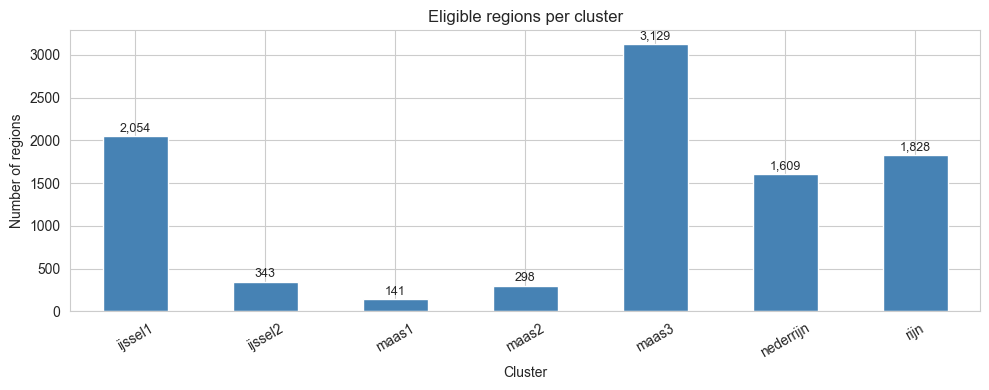

In [4]:
cluster_counts = features['cluster'].value_counts().reindex(CLUSTERS + ['other']).dropna()

print('Eligible regions per cluster (before split):')
print(f'  {"cluster":<12} {"n_regions":<12} {"% of eligible"}')
for cluster, count in cluster_counts.items():
    pct = count / len(features) * 100
    bar = '█' * int(pct / 2)
    print(f'  {cluster:<12} {int(count):<12,} {pct:>5.1f}%  {bar}')

fig, ax = plt.subplots(figsize=(10, 4))
cluster_counts.plot.bar(ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Eligible regions per cluster')
ax.set_xlabel('Cluster')
ax.set_ylabel('Number of regions')
ax.tick_params(axis='x', rotation=30)
for bar in ax.patches:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
            f'{int(bar.get_height()):,}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

## 5. Stratified 80/20 split

Split result per cluster:


split,train,train_%,test,test_%,total
cluster,,,,,
ijssel1,1643.0,80.0,411.0,20.0,2054.0
ijssel2,274.0,79.9,69.0,20.1,343.0
maas1,113.0,80.1,28.0,19.9,141.0
maas2,239.0,80.2,59.0,19.8,298.0
maas3,2503.0,80.0,626.0,20.0,3129.0
nederrijn,1287.0,80.0,322.0,20.0,1609.0
rijn,1462.0,80.0,366.0,20.0,1828.0
TOTAL,7521.0,80.0,1881.0,20.0,9402.0


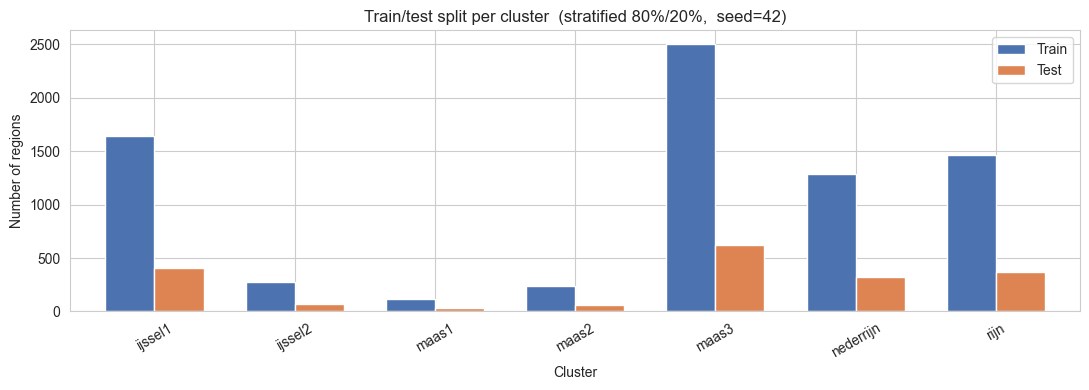

In [5]:
train_idx, test_idx = train_test_split(
    features.index,
    test_size    = TEST_SIZE,
    random_state = RANDOM_SEED,
    stratify     = features['cluster'],
)

features['split'] = 'train'
features.loc[test_idx, 'split'] = 'test'

# ── Verify split counts per cluster ──────────────────────────────────────────
split_counts = features.groupby(['cluster','split']).size().unstack(fill_value=0)
split_counts['total']   = split_counts.sum(axis=1)
split_counts['test_%']  = (split_counts['test'] / split_counts['total'] * 100).round(1)
split_counts['train_%'] = (split_counts['train'] / split_counts['total'] * 100).round(1)

# Add total row
totals = split_counts[['train','test','total']].sum()
totals['test_%']  = round(totals['test']  / totals['total'] * 100, 1)
totals['train_%'] = round(totals['train'] / totals['total'] * 100, 1)
split_counts.loc['TOTAL'] = totals

print('Split result per cluster:')
display(split_counts[['train','train_%','test','test_%','total']])

# ── Visual ───────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 4))
plot_data = split_counts.drop('TOTAL')[['train','test']]
plot_data.plot.bar(ax=ax, color=['#4c72b0','#dd8452'], edgecolor='white', width=0.7)
ax.set_title(f'Train/test split per cluster  (stratified {1-TEST_SIZE:.0%}/{TEST_SIZE:.0%},  seed={RANDOM_SEED})')
ax.set_xlabel('Cluster')
ax.set_ylabel('Number of regions')
ax.tick_params(axis='x', rotation=30)
ax.legend(['Train','Test'])
plt.tight_layout()
plt.show()

## 6. Sanity checks

Verify the split didn't accidentally skew the velocity distributions.

## 6b. NVO check — are nature-friendly banks fairly represented?

NVO (Natuurvriendelijke Oevers) regions are identified from the `vvr_rates_of_change` layer
in `20260303_model_results.gpkg`. The `predicted_bank_positions` layer in the same file already
carries an `is_nvo` flag per `location_id`, so no spatial join is required.

We check:
1. How many eligible regions are NVO, and how that maps to clusters
2. Whether the 80/20 stratified split preserved the NVO fraction correctly

NVO regions in eligible set: 2,310 / 9,402  (24.6%)
Non-NVO regions            : 7,092

NVO breakdown per cluster:


,n_total,n_nvo,nvo_pct
cluster,,,
ijssel1,2054,417,20.3
ijssel2,343,0,0.0
maas1,141,4,2.8
maas2,298,80,26.8
maas3,3129,1604,51.3
nederrijn,1609,130,8.1
rijn,1828,75,4.1



NVO fraction per split:


,n_total,n_nvo,nvo_pct
split,,,
test,1881,475,25.25
train,7521,1835,24.40


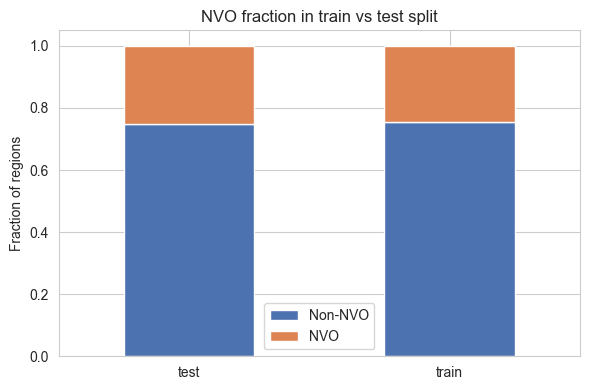


✅ is_nvo column added to features table.


In [ ]:
import geopandas as gpd

MODEL_GPKG = PATHS.DATA_DIR / '04_model_outputs/20260303/20260303_model_results.gpkg'

# ── Build location_id → is_nvo lookup from predicted_bank_positions ───────────
pbp = gpd.read_file(MODEL_GPKG, layer='predicted_bank_positions', columns=['location_id', 'is_nvo'])
nvo_lookup = pbp.drop_duplicates('location_id').set_index('location_id')['is_nvo']

# ── Add is_nvo to the split table ─────────────────────────────────────────────
features['is_nvo'] = features.index.map(nvo_lookup).fillna(False).astype(bool)

n_nvo   = features['is_nvo'].sum()
n_total = len(features)
print(f'NVO regions in eligible set: {n_nvo:,} / {n_total:,}  ({n_nvo/n_total*100:.1f}%)')
print(f'Non-NVO regions            : {n_total - n_nvo:,}')

# ── NVO count per cluster ──────────────────────────────────────────────────────
print('\nNVO breakdown per cluster:')
nvo_by_cluster = features.groupby('cluster').agg(
    n_total = ('is_nvo', 'count'),
    n_nvo   = ('is_nvo', 'sum'),
).assign(nvo_pct=lambda d: (d['n_nvo'] / d['n_total'] * 100).round(1))
display(nvo_by_cluster)

# ── NVO fraction in train vs test ─────────────────────────────────────────────
print('\nNVO fraction per split:')
nvo_split = features.groupby('split').agg(
    n_total = ('is_nvo', 'count'),
    n_nvo   = ('is_nvo', 'sum'),
).assign(nvo_pct=lambda d: (d['n_nvo'] / d['n_total'] * 100).round(2))
display(nvo_split)

# Visual: stacked bar — NVO vs non-NVO fraction per split
fig, ax = plt.subplots(figsize=(6, 4))
nvo_fracs = features.groupby(['split', 'is_nvo']).size().unstack(fill_value=0)
nvo_fracs.div(nvo_fracs.sum(axis=1), axis=0).plot.bar(
    ax=ax, stacked=True, color=['#4c72b0', '#dd8452'], edgecolor='white', width=0.5
)
ax.set_title('NVO fraction in train vs test split')
ax.set_xlabel('')
ax.set_ylabel('Fraction of regions')
ax.legend(['Non-NVO', 'NVO'])
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

print('\n✅ is_nvo column added to features table.')

Distribution check — v_train and v_test should look similar in train and test sets:
                     value
train v_train mean  -0.120
test  v_train mean  -0.183
train v_test  mean   0.813
test  v_test  mean   1.112
train dist_t2 mean  97.702
test  dist_t2 mean  96.619


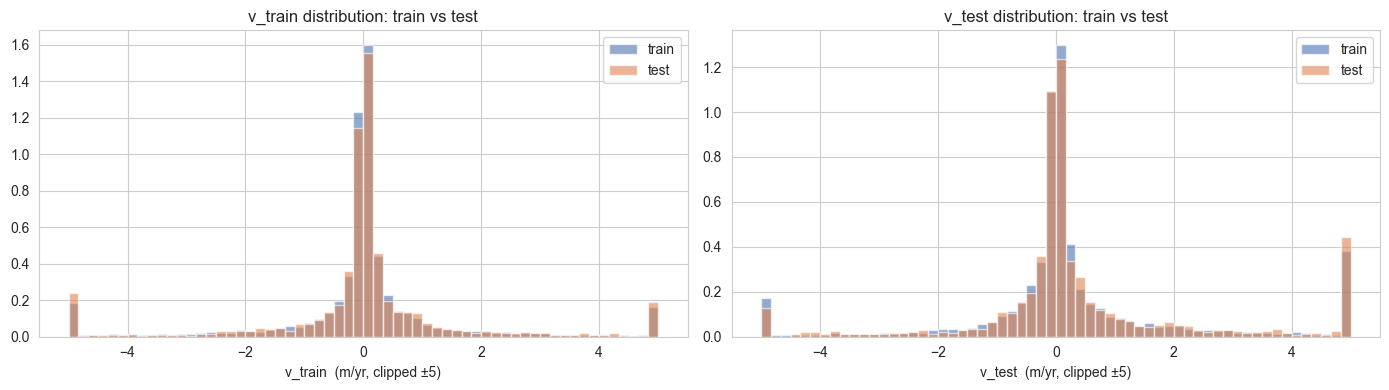

In [11]:
train = features[features['split'] == 'train']
test  = features[features['split'] == 'test']

print('Distribution check — v_train and v_test should look similar in train and test sets:')
check = pd.DataFrame({
    'train v_train mean'  : [train['v_train'].mean()],
    'test  v_train mean'  : [test['v_train'].mean()],
    'train v_test  mean'  : [train['v_test'].mean()],
    'test  v_test  mean'  : [test['v_test'].mean()],
    'train dist_t2 mean'  : [train['dist_t2'].mean()],
    'test  dist_t2 mean'  : [test['dist_t2'].mean()],
}).T.rename(columns={0: 'value'})
print(check.round(3).to_string())

# Histogram comparison
CLIP = 5
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, col, title in [
    (axes[0], 'v_train', 'v_train distribution: train vs test'),
    (axes[1], 'v_test',  'v_test distribution: train vs test'),
]:
    train[col].clip(-CLIP, CLIP).hist(bins=60, ax=ax, alpha=0.6, color='#4c72b0', label='train', density=True)
    test[col].clip(-CLIP, CLIP).hist( bins=60, ax=ax, alpha=0.6, color='#dd8452', label='test',  density=True)
    ax.set_title(title)
    ax.set_xlabel(f'{col}  (m/yr, clipped ±{CLIP})')
    ax.legend()

plt.tight_layout()
plt.show()

## 7. Save

In [12]:
# Save eligible split
features.to_parquet(SPLIT_OUT)
print(f'✅ Saved region_split.parquet')
print(f'   Path   : {SPLIT_OUT}')
print(f'   Rows   : {len(features):,}')
print(f'   Train  : {(features["split"]=="train").sum():,}')
print(f'   Test   : {(features["split"]=="test").sum():,}')
print(f'   Columns: {list(features.columns)}')

# Save inference-only
inference_df.to_parquet(INFERENCE_OUT)
print(f'\n✅ Saved region_inference_only.parquet')
print(f'   Path   : {INFERENCE_OUT}')
print(f'   Rows   : {len(inference_df):,}')

print(f'\n⚠️  Do not re-run this notebook unless you intend to change the split.')
print(f'   All model notebooks load region_split.parquet directly.')

✅ Saved region_split.parquet
   Path   : /Users/admin/Documents/work/Moraine/oevererosie/wocu-oevererosie/backend/data/02_processed/erosion/region_split.parquet
   Rows   : 9,402
   Train  : 7,521
   Test   : 1,881
   Columns: ['cluster', 'n_timestamps', 't1', 't2', 't3', 'train_span_yr', 'test_span_yr', 'dist_t1', 'dist_t2', 'dist_t3', 'v_train', 'v_test', 'split', 'is_nvo']

✅ Saved region_inference_only.parquet
   Path   : /Users/admin/Documents/work/Moraine/oevererosie/wocu-oevererosie/backend/data/02_processed/erosion/region_inference_only.parquet
   Rows   : 1,082

⚠️  Do not re-run this notebook unless you intend to change the split.
   All model notebooks load region_split.parquet directly.
